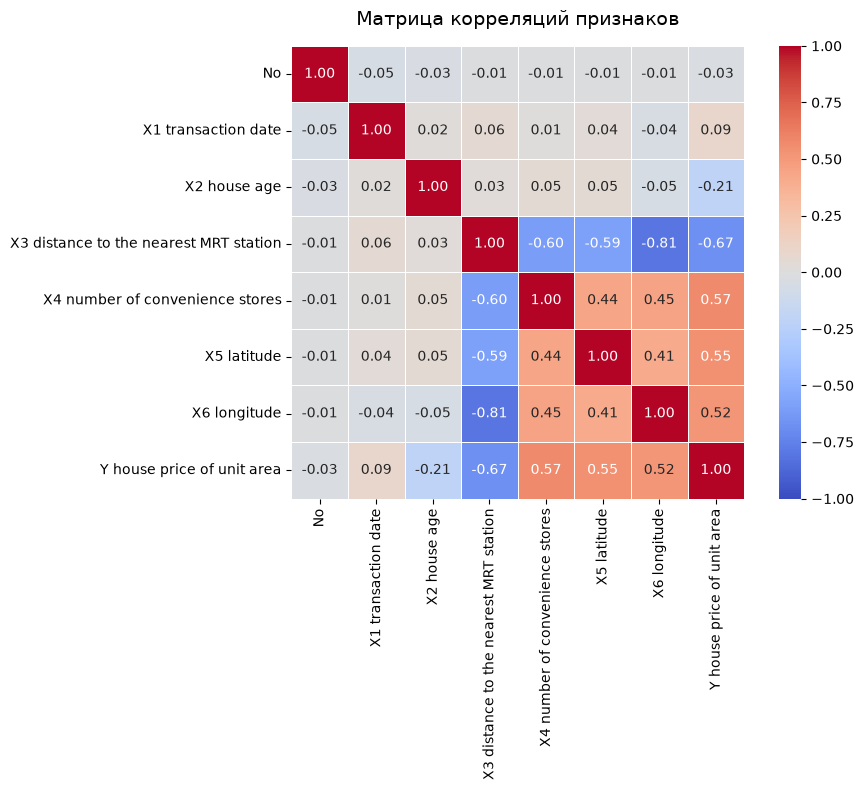

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Real estate.csv')
corr_matrix = df.corr(numeric_only=True)


plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,         
    fmt=".2f",          
    cmap="coolwarm",    
    vmin=-1, vmax=1,    
    linewidths=0.5,     
    square=True         
)

plt.title("Матрица корреляций признаков", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


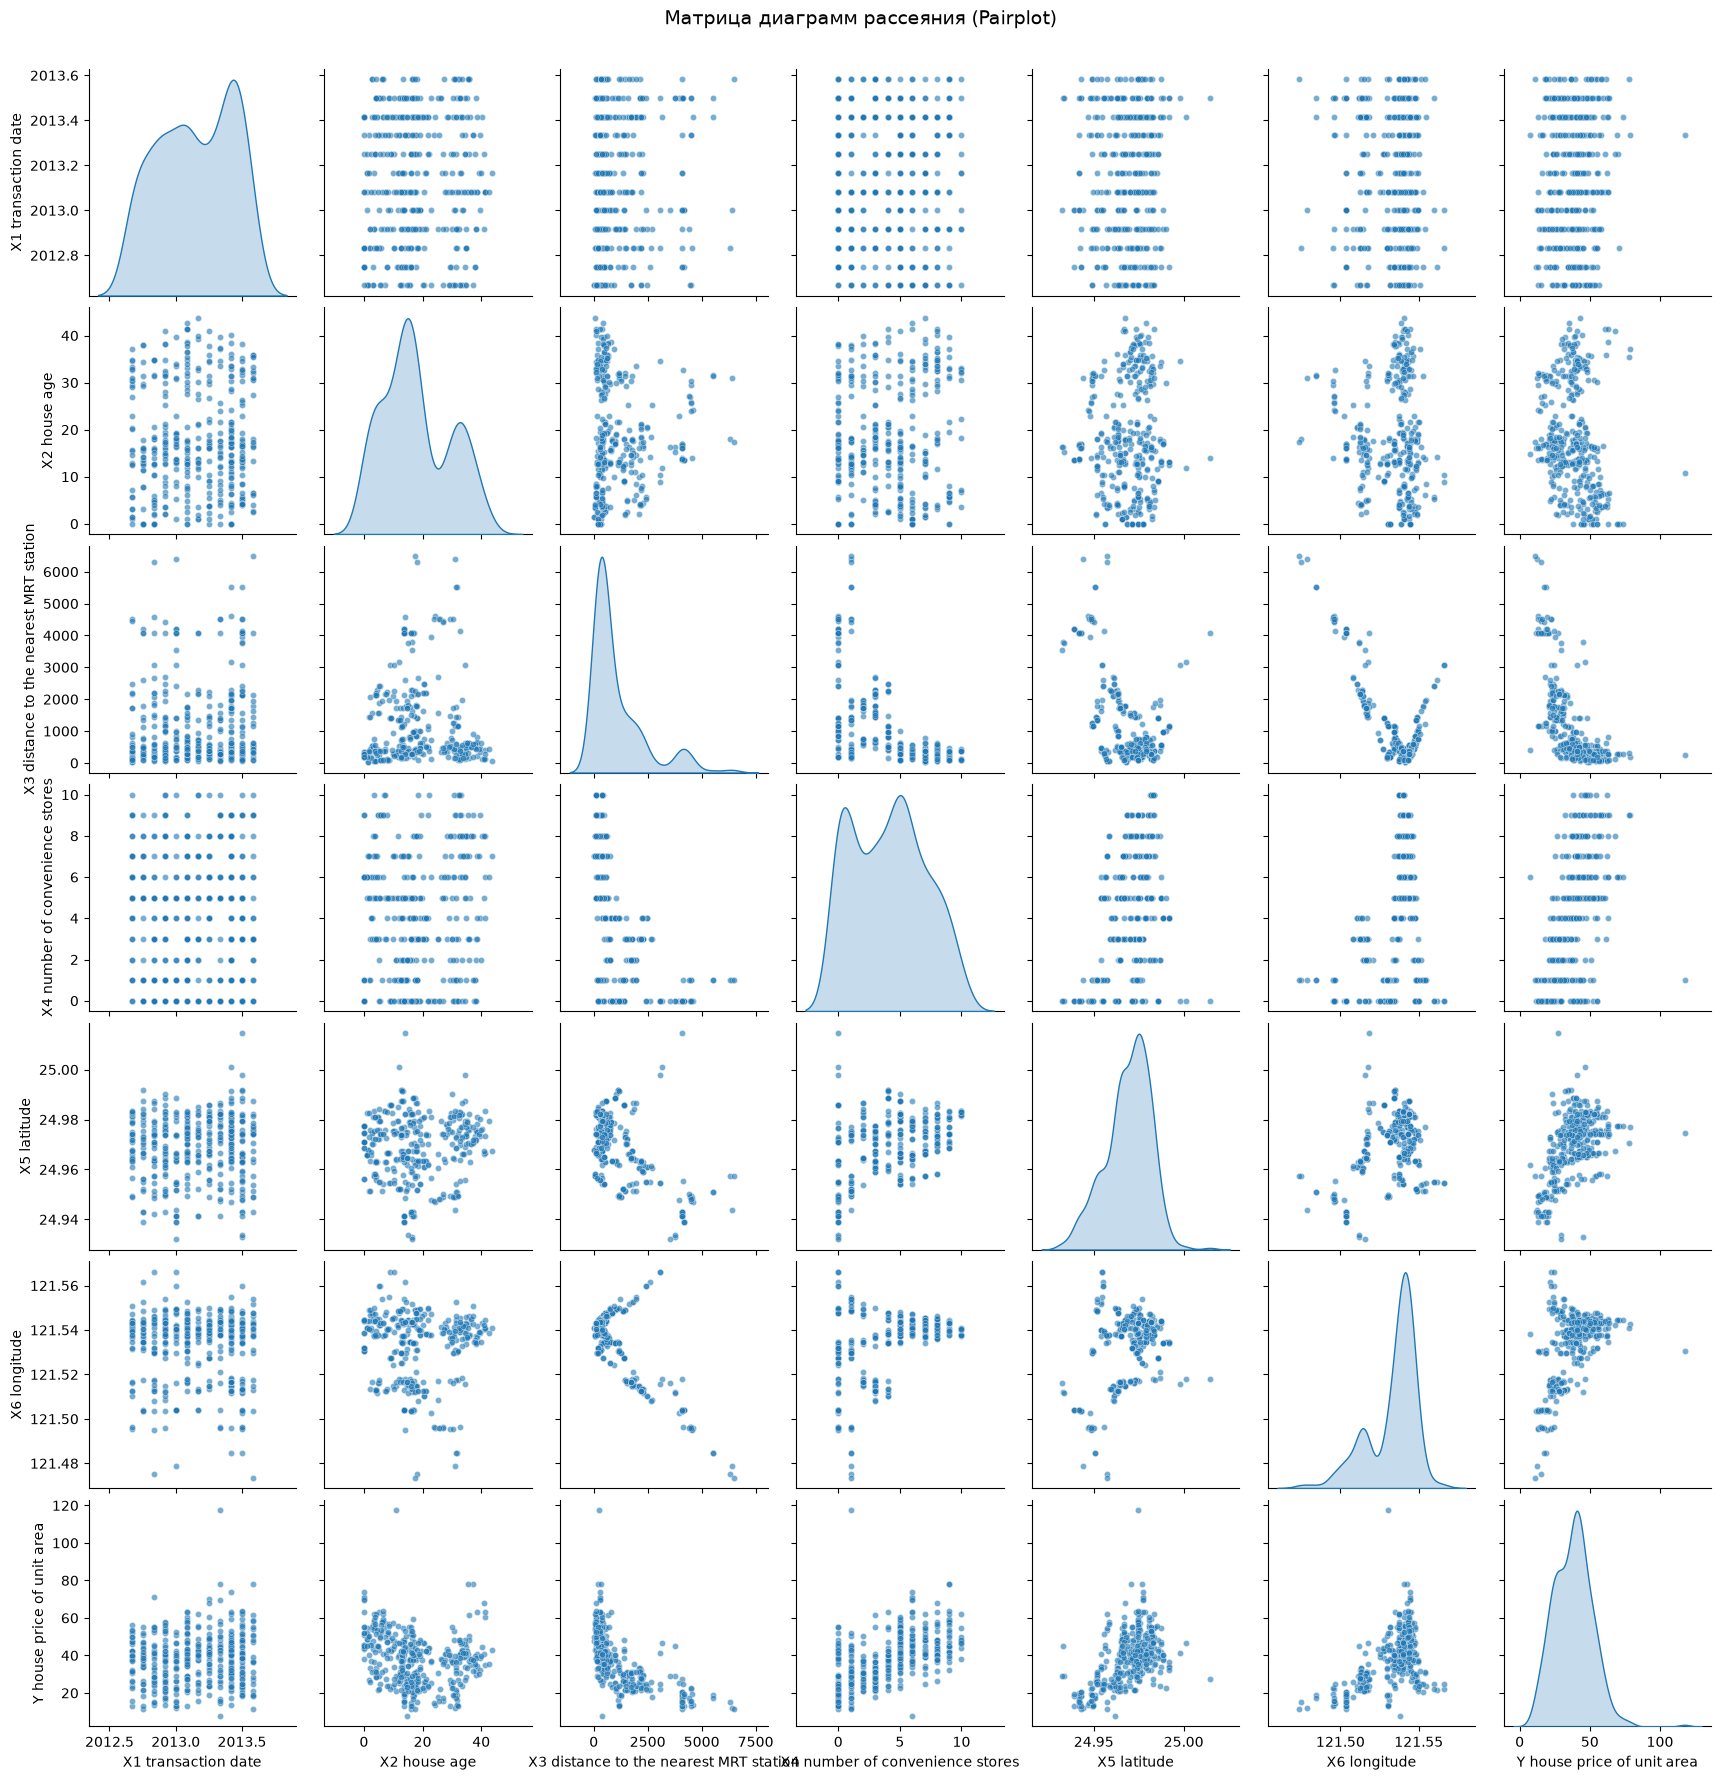

In [4]:
df_clean = df.drop(columns=['No'], errors='ignore')

sns.pairplot(
    df_clean, 
    diag_kind='kde',      
    plot_kws={'alpha': 0.6, 's': 20} 
)

plt.suptitle("Матрица диаграмм рассеяния (Pairplot)", y=1.02, fontsize=14)
plt.show()

Уравнение регрессии: Y = 27.18 + 2.64 * X4
Коэффициент детерминации (R²): 0.326
Ошибка RMSE: 11.16


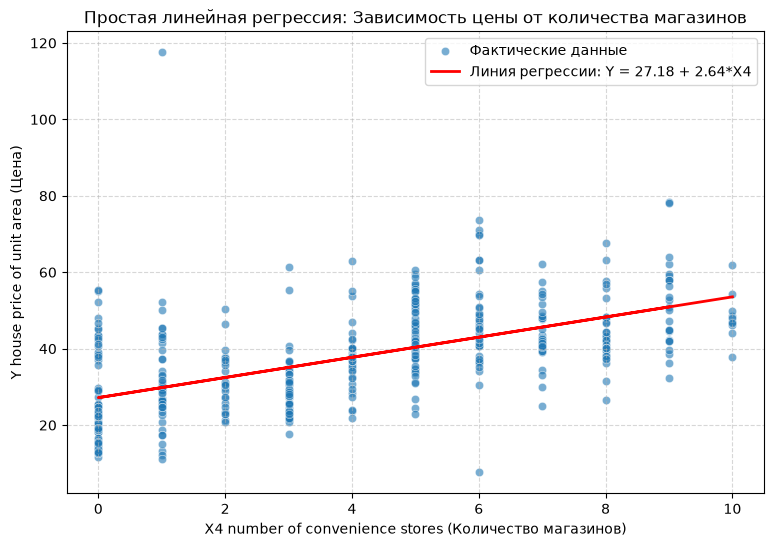

In [5]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[['X4 number of convenience stores']] 
y = df['Y house price of unit area']        

model = LinearRegression()
model.fit(X, y)

w0 = model.intercept_
w1 = model.coef_[0]

print(f"Уравнение регрессии: Y = {w0:.2f} + {w1:.2f} * X4")

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"Коэффициент детерминации (R²): {r2:.3f}")
print(f"Ошибка RMSE: {rmse:.2f}")

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X['X4 number of convenience stores'], y=y, alpha=0.6, label='Фактические данные')
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Линия регрессии: Y = {w0:.2f} + {w1:.2f}*X4')

plt.title('Простая линейная регрессия: Зависимость цены от количества магазинов', fontsize=12)
plt.xlabel('X4 number of convenience stores (Количество магазинов)')
plt.ylabel('Y house price of unit area (Цена)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== Коэффициенты множественной линейной регрессии ===
Свободный член (Intercept w0): -5916.0065

Вес X3 distance to the nearest MRT station (w): -0.0042
Вес X4 number of convenience stores (w): 1.1648
Вес X2 house age (w): -0.2687
Вес X5 latitude (w): 238.6357

=== Метрики качества модели ===
Коэффициент детерминации (R²): 0.5711
Ошибка RMSE: 8.8998


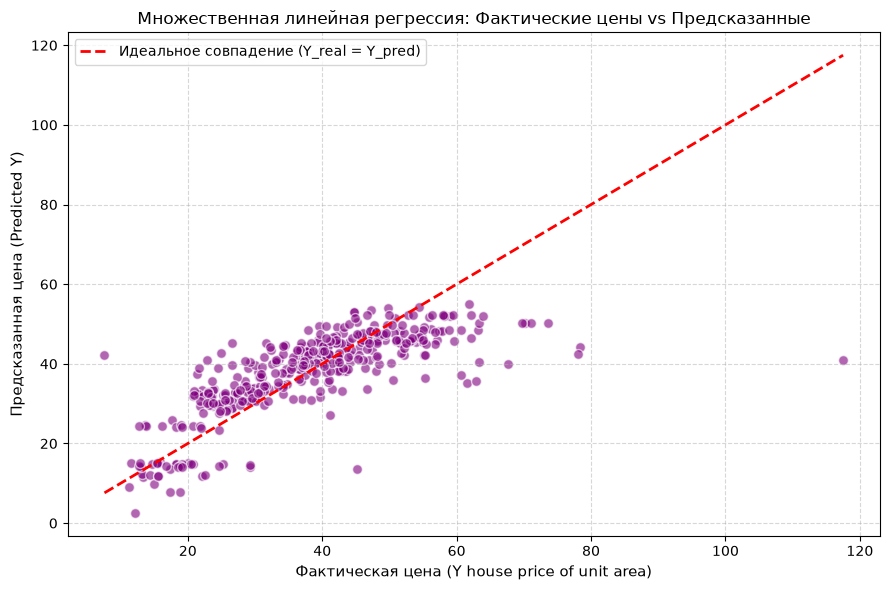

In [8]:
df = pd.read_csv('Real estate.csv')

feature_cols = [
    'X3 distance to the nearest MRT station',
    'X4 number of convenience stores',
    'X2 house age',
    'X5 latitude'
]

X_multi = df[feature_cols]
y = df['Y house price of unit area']

multi_model = LinearRegression()
multi_model.fit(X_multi, y)

print("=== Коэффициенты множественной линейной регрессии ===")
print(f"Свободный член (Intercept w0): {multi_model.intercept_:.4f}\n")

for col, coef in zip(feature_cols, multi_model.coef_):
    print(f"Вес {col} (w): {coef:.4f}")

y_pred_multi = multi_model.predict(X_multi)
r2_multi = r2_score(y, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y, y_pred_multi))

print("\n=== Метрики качества модели ===")
print(f"Коэффициент детерминации (R²): {r2_multi:.4f}")
print(f"Ошибка RMSE: {rmse_multi:.4f}")

# 6. Визуализация: Сравнение реальных цен и предсказанных моделью
plt.figure(figsize=(9, 6))
plt.scatter(y, y_pred_multi, alpha=0.6, color='purple', edgecolor='w', s=50)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Идеальное совпадение (Y_real = Y_pred)')

plt.title('Множественная линейная регрессия: Фактические цены vs Предсказанные', fontsize=12)
plt.xlabel('Фактическая цена (Y house price of unit area)', fontsize=11)
plt.ylabel('Предсказанная цена (Predicted Y)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()